In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/madrid_airbnb_enriched.csv')

print(df.shape)
df.info()



(19618, 21)
<class 'pandas.DataFrame'>
RangeIndex: 19618 entries, 0 to 19617
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              19618 non-null  int64  
 1   name                            19618 non-null  str    
 2   host_id                         19618 non-null  int64  
 3   host_name                       19618 non-null  str    
 4   neighbourhood_group             19618 non-null  str    
 5   neighbourhood                   19618 non-null  str    
 6   latitude                        19618 non-null  float64
 7   longitude                       19618 non-null  float64
 8   room_type                       19618 non-null  str    
 9   price                           19594 non-null  float64
 10  minimum_nights                  19618 non-null  int64  
 11  number_of_reviews               19618 non-null  int64  
 12  last_review                    

In [2]:
df[df['price'].isnull()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,poblacion_total,renta_media_hogar,alquiler_medio_mes,tiene_gran_recinto,total_vut
181,578731,"CENTRIC, QUIET, BRIGHT APARTMENT.",2847013,Santiago,Centro,Universidad,40.42551,-3.70812,Entire home/apt,NaN,...,338,2020-03-15,3.19,5,105,141800,44958,825.00,1,218
412,1101760,GREAT ATTIC-BARRIO DE LAS LETRA,2847013,Santiago,Centro,Cortes,40.41340,-3.69730,Entire home/apt,NaN,...,312,2020-03-18,3.22,5,106,141800,44958,825.00,1,218
1457,6532332,"SUNNY TERRACE, PARKING - LOCATION!",2847013,Santiago,Centro,Embajadores,40.40902,-3.69839,Entire home/apt,NaN,...,237,2020-03-08,3.30,5,107,141800,44958,825.00,1,218
2544,11604203,Precioso piso céntrico WIFI (1ero Izq),24619741,Begoña,Centro,Cortes,40.41288,-3.69848,Entire home/apt,NaN,...,234,2020-07-28,3.86,3,0,141800,44958,825.00,1,218
2927,13221821,CENTRE OF MADRID. SANTA ANA AND SOL,74180884,Antonio,Centro,Cortes,40.41406,-3.70294,Entire home/apt,NaN,...,182,2020-03-13,3.09,2,104,141800,44958,825.00,1,218
3704,15645521,Wonderful Location: Atocha/Museums/Retiro,100942694,David,Arganzuela,Palos de Moguer,40.40530,-3.69149,Entire home/apt,NaN,...,181,2020-03-08,3.32,1,104,158550,52857,850.00,0,121
4043,16673027,Tu casa en el Barrio de Las Letras (2 izq),24619741,Begoña,Centro,Cortes,40.41346,-3.69810,Entire home/apt,NaN,...,164,2020-05-03,3.16,3,0,141800,44958,825.00,1,218
4056,16716492,Precioso Piso en el Corazón del Arte (3ero I),24619741,Begoña,Centro,Cortes,40.41206,-3.69649,Entire home/apt,NaN,...,69,2020-04-26,1.34,3,105,141800,44958,825.00,1,218
4088,16810981,LIFE STYLE CENTER,111803297,Doris,Arganzuela,Delicias,40.39821,-3.69490,Entire home/apt,NaN,...,54,2020-12-31,1.07,1,104,158550,52857,850.00,0,121
4150,17032306,6Pax-3Double Room+Parking+WiFi.Nice&cozy apart...,3053459,Francisco,Carabanchel,Comillas,40.39550,-3.71421,Entire home/apt,NaN,...,137,2020-04-30,2.71,1,43,278090,36350,650.00,0,85


In [3]:
df[df['price'].isnull()][['room_type', 'minimum_nights', 'number_of_reviews', 'availability_365']]

,room_type,minimum_nights,number_of_reviews,availability_365
181,Entire home/apt,2,338,105
412,Entire home/apt,2,312,106
1457,Entire home/apt,2,237,107
2544,Entire home/apt,1,234,0
2927,Entire home/apt,2,182,104
3704,Entire home/apt,2,181,104
4043,Entire home/apt,1,164,0
4056,Entire home/apt,1,69,105
4088,Entire home/apt,2,54,104
4150,Entire home/apt,1,137,43


In [5]:
df[df['price'].isnull()]['room_type'].value_counts()

room_type
Entire home/apt    16
Hotel room          8
Name: count, dtype: int64

In [6]:
# Calcular la mediana de precio por distrito y tipo de habitación
medianas = df.groupby(['neighbourhood_group', 'room_type'])['price'].median()

# Función para imputar usando esa mediana
def imputar_precio(row):
    if pd.isnull(row['price']):
        return medianas.loc[row['neighbourhood_group'], row['room_type']]
    return row['price']

df['price'] = df.apply(imputar_precio, axis=1)

# Verificar que ya no quedan nulos
print(df['price'].isnull().sum())

1


In [7]:
df[df['price'].isnull()][['neighbourhood_group', 'room_type']]

,neighbourhood_group,room_type
15912,Moratalaz,Hotel room


In [8]:
# Fallback: mediana global por tipo de habitación, para los casos sin match en su distrito
mediana_global = df.groupby('room_type')['price'].median()

df['price'] = df.apply(
    lambda row: mediana_global[row['room_type']] if pd.isnull(row['price']) else row['price'],
    axis=1
)

print(df['price'].isnull().sum())

0


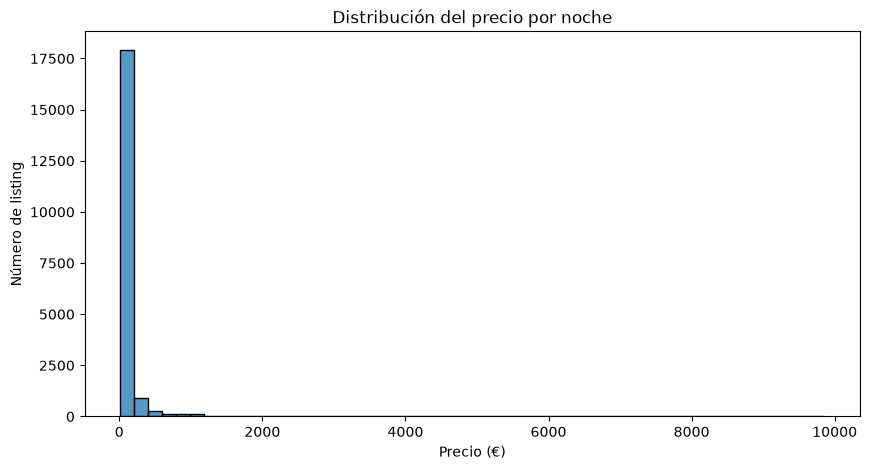

count    19618.000000
mean       121.213375
std        393.542936
min          8.000000
25%         35.000000
50%         58.000000
75%        100.000000
max       9856.000000
Name: price, dtype: float64


In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50)
plt.title('Distribución del precio por noche')
plt.xlabel('Precio (€)')
plt.ylabel('Número de listing')
plt.show()

print(df['price'].describe())

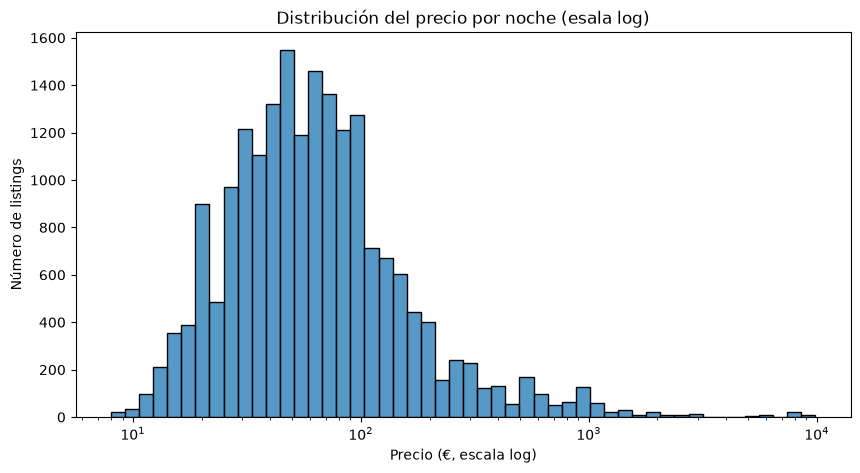

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, log_scale=True)
plt.title('Distribución del precio por noche (esala log)')
plt.xlabel('Precio (€, escala log)')
plt.ylabel('Número de listings')
plt.show()

In [12]:
print((df['price'] > 500).sum(), "listings con precio > 500€")
print((df['price'] > 1000).sum(), "listings con precio > 1000€")

594 listings con precio > 500€
212 listings con precio > 1000€


In [13]:
# Vista filtrada solo para visualización - no modifica df, es una copia auxiliar
df_viz = df[df['price'] <=500]
print (df_viz.shape)

(19024, 21)


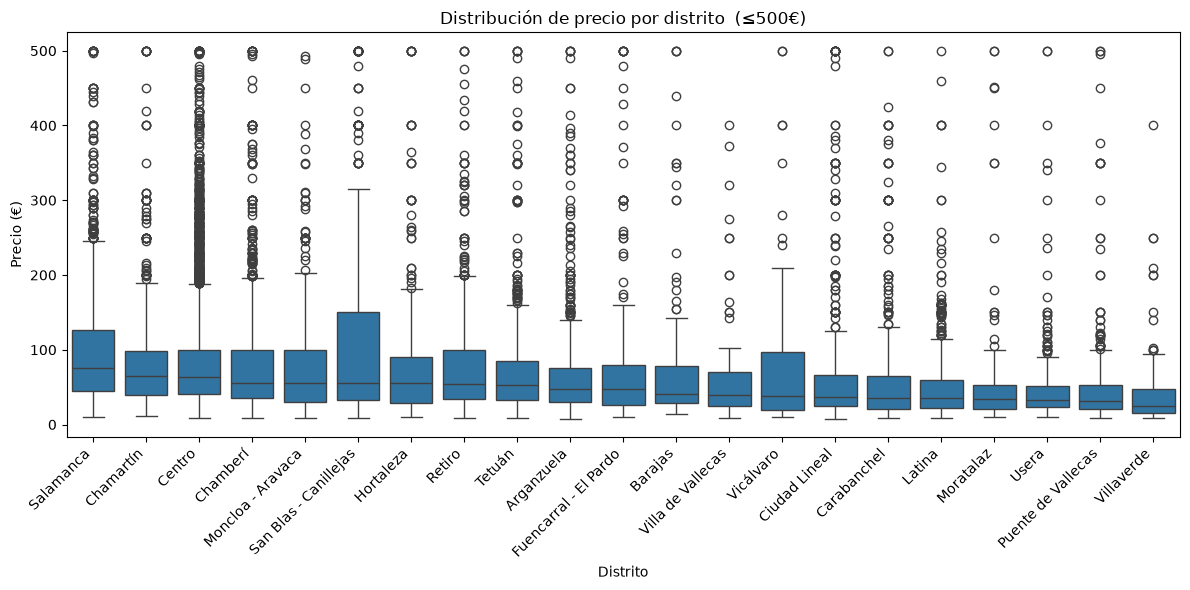

In [14]:
plt.figure(figsize=(12, 6))
orden = df_viz.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_viz, x='neighbourhood_group', y='price', order=orden)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de precio por distrito  (≤500€)')
plt.xlabel('Distrito')
plt.ylabel('Precio (€)')
plt.tight_layout()
plt.show()



In [15]:
precio_medio_distrito = df_viz.groupby('neighbourhood_group').agg(
    precio_mediano=('price', 'median'),
    renta_media=('renta_media_hogar', 'first'),
    poblacion=('poblacion_total', 'first'),
    total_vut=('total_vut', 'first')
).sort_values('precio_mediano', ascending=False)

precio_medio_distrito

,precio_mediano,renta_media,poblacion,total_vut
neighbourhood_group,,,,
Salamanca,76.0,69147,147256,79
Chamartín,65.0,79274,148093,109
Centro,64.0,44958,141800,218
Chamberí,55.0,65174,141522,60
Moncloa - Aravaca,55.0,71711,126257,24
San Blas - Canillejas,55.0,44468,168526,18
Hortaleza,55.0,61472,209178,28
Retiro,54.0,64787,118863,40
Tetuán,53.0,45762,167776,177


In [16]:
df_viz['neighbourhood'].value_counts()

neighbourhood
Embajadores      2252
Universidad      1830
Palacio          1478
Sol              1103
Justicia          930
                 ... 
Valdemarín          5
Fuentelareina       5
El Pardo            3
Horcajo             2
Atalaya             1
Name: count, Length: 128, dtype: int64

In [17]:
df_viz['neighbourhood_group'].value_counts()

neighbourhood_group
Centro                   8444
Salamanca                1284
Chamberí                 1214
Arganzuela               1086
Tetuán                    791
Carabanchel               701
Retiro                    656
Ciudad Lineal             625
Puente de Vallecas        603
Latina                    593
Chamartín                 561
Moncloa - Aravaca         539
San Blas - Canillejas     397
Hortaleza                 342
Fuencarral - El Pardo     302
Usera                     275
Villaverde                169
Barajas                   164
Moratalaz                 114
Villa de Vallecas          97
Vicálvaro                  67
Name: count, dtype: int64

In [18]:
precio_medio_distrito

,precio_mediano,renta_media,poblacion,total_vut
neighbourhood_group,,,,
Salamanca,76.0,69147,147256,79
Chamartín,65.0,79274,148093,109
Centro,64.0,44958,141800,218
Chamberí,55.0,65174,141522,60
Moncloa - Aravaca,55.0,71711,126257,24
San Blas - Canillejas,55.0,44468,168526,18
Hortaleza,55.0,61472,209178,28
Retiro,54.0,64787,118863,40
Tetuán,53.0,45762,167776,177


Correlación precio-renta: 0.758


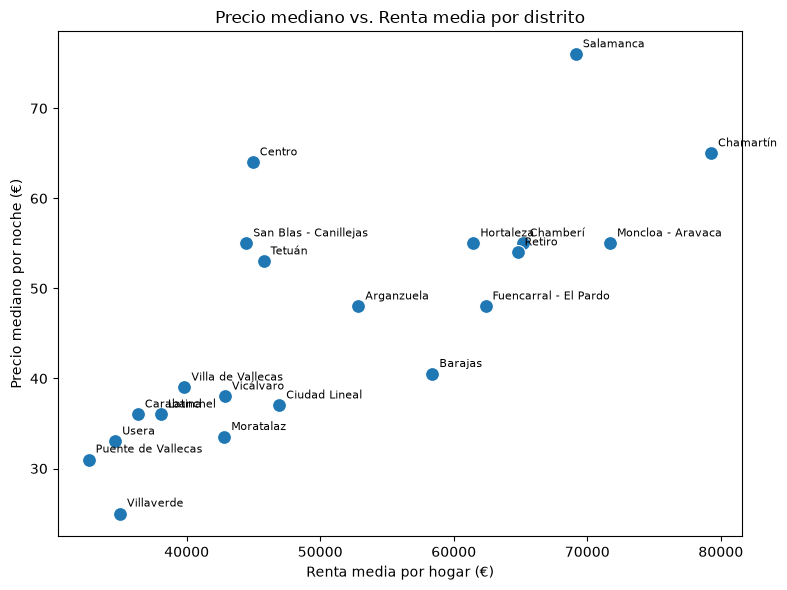

In [19]:
correlacion = precio_medio_distrito['precio_mediano'].corr(precio_medio_distrito['renta_media'])
print(f"Correlación precio-renta: {correlacion:.3f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=precio_medio_distrito, x='renta_media', y='precio_mediano', s=100)

# Etiquetar cada punto con el nombre del distrito
for distrito, row in precio_medio_distrito.iterrows():
    plt.annotate(distrito, (row['renta_media'], row['precio_mediano']), fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.title('Precio mediano vs. Renta media por distrito')
plt.xlabel('Renta media por hogar (€)')
plt.ylabel('Precio mediano por noche (€)')
plt.tight_layout()
plt.show()

Correlación precio-VUT: 0.358


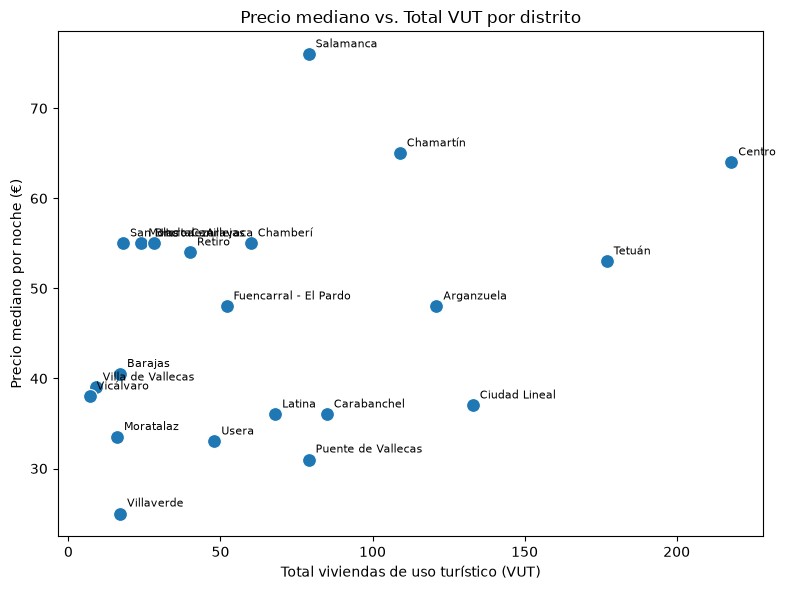

In [20]:
correlacion_vut = precio_medio_distrito['precio_mediano'].corr(precio_medio_distrito['total_vut'])
print(f"Correlación precio-VUT: {correlacion_vut:.3f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=precio_medio_distrito, x='total_vut', y='precio_mediano', s=100)

for distrito, row in precio_medio_distrito.iterrows():
    plt.annotate(distrito, (row['total_vut'], row['precio_mediano']), fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.title('Precio mediano vs. Total VUT por distrito')
plt.xlabel('Total viviendas de uso turístico (VUT)')
plt.ylabel('Precio mediano por noche (€)')
plt.tight_layout()
plt.show()

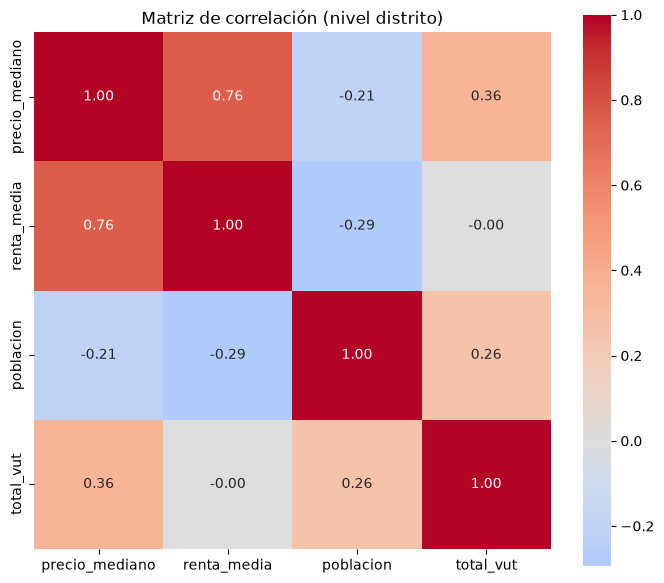

In [21]:
variables_corr = ['precio_mediano', 'renta_media', 'poblacion', 'total_vut']
matriz_corr = precio_medio_distrito[variables_corr].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Matriz de correlación (nivel distrito)')
plt.tight_layout()
plt.show()

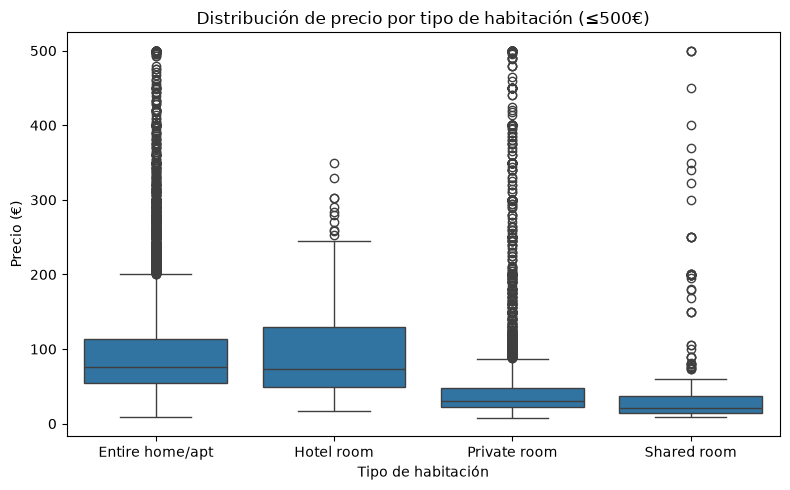

                 median        mean  count
room_type                                 
Entire home/apt    76.0   97.509357  10954
Hotel room         73.5  100.246622    148
Private room       31.0   53.394055   7603
Shared room        21.0   49.645768    319


In [24]:
plt.figure(figsize=(8, 5))
orden_rt = df_viz.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_viz, x='room_type', y='price', order=orden_rt)
plt.title('Distribución de precio por tipo de habitación (≤500€)')
plt.xlabel('Tipo de habitación')
plt.ylabel('Precio (€)')
plt.tight_layout()
plt.show()

print(df_viz.groupby('room_type')['price'].agg(['median', 'mean', 'count']).sort_values('median', ascending=False))

In [26]:
tabla_room_distrito = pd.crosstab(df_viz['neighbourhood_group'], df_viz['room_type'], normalize='index') * 100
tabla_room_distrito = tabla_room_distrito.round(1)
tabla_room_distrito

room_type,Entire home/apt,Hotel room,Private room,Shared room
neighbourhood_group,,,,
Arganzuela,51.3,0.2,47.3,1.2
Barajas,31.1,0.0,67.7,1.2
Carabanchel,36.9,0.0,62.2,0.9
Centro,69.7,1.3,26.9,2.1
Chamartín,59.2,0.7,38.0,2.1
Chamberí,55.3,0.7,42.3,1.8
Ciudad Lineal,31.0,0.2,66.9,1.9
Fuencarral - El Pardo,40.1,0.0,59.6,0.3
Hortaleza,40.6,1.5,57.6,0.3


In [27]:
print(df['minimum_nights'].describe())
print()
print("Listings con minimum_nights > 30:", (df['minimum_nights'] > 30).sum())
print("Listings con minimum_nights > 90:", (df['minimum_nights'] > 90).sum())
print("Listings con minimum_nights = 365 (o más):", (df['minimum_nights'] >= 365).sum())

count    19618.000000
mean         6.586196
std         33.286582
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max       1125.000000
Name: minimum_nights, dtype: float64

Listings con minimum_nights > 30: 317
Listings con minimum_nights > 90: 119
Listings con minimum_nights = 365 (o más): 41


## Conclusiones del análisis exploratorio (EDA)

Este análisis explora el dataset enriquecido de Airbnb Madrid (19.618 listings, 21 variables) combinando los datos originales de la plataforma con cinco variables socioeconómicas y urbanísticas a nivel de distrito.

### 1. Calidad de datos
- `price` presentaba 24 valores nulos, sin patrón evidente de distrito u host. Se imputaron con la mediana de precio por distrito y `room_type`; un caso (Moratalaz, Hotel room) se resolvió con la mediana global por falta de referencia local.
- `last_review` tiene 5.637 nulos, correspondientes a listings sin reseñas — no es un error de datos, sino la ausencia esperable de actividad.

### 2. Distribución de precios
El precio por noche sigue una distribución fuertemente asimétrica (log-normal): mediana de 58€ frente a una media de 121€, inflada por una cola de valores extremos (máximo 9.856€). El 75% de los listings cuesta 100€ o menos. Para las visualizaciones se utilizó un subconjunto filtrado (`price` ≤ 500€, un 97% del dataset) y se priorizó la mediana sobre la media como medida de tendencia central.

### 3. Precio por distrito
Salamanca, Chamartín y Centro presentan los precios medianos más altos; Villaverde, Puente de Vallecas y Usera, los más bajos. Centro concentra el 43% de todos los listings del dataset, reflejo de su peso turístico.

### 4. Relación entre precio y variables socioeconómicas
- **Precio vs. renta media del distrito**: correlación de **0,76** — la relación más fuerte del análisis. El nivel socioeconómico del distrito es el mejor predictor del precio entre las variables estudiadas.
- **Precio vs. total VUT (viviendas de uso turístico)**: correlación de **0,36**, notablemente más débil. La cantidad de oferta turística legal no explica el precio tanto como la renta.
- **Precio vs. población**: correlación débil-negativa (**-0,21**) — distritos más poblados (periféricos) tienden a precios algo más bajos.
- Centro es una excepción destacable: renta media-baja (~45.000€) pero precio relativamente alto (64€), atribuible a su carácter turístico más que residencial.

### 5. Tipo de alojamiento
`Entire home/apt` y `Hotel room` tienen precios medianos similares (76€ y 73,5€), muy por encima de `Private room` (31€) y `Shared room` (21€). La distribución por distrito refuerza el patrón socioeconómico: Centro y Salamanca concentran la mayor proporción de pisos completos (69,7% y 68,8%), mientras que distritos periféricos como Vicálvaro y Moratalaz predominan en habitaciones privadas (82,1% y 74,6%).

### 6. Estancias mínimas: turismo vs. alquiler de larga duración
La mediana de `minimum_nights` es de solo 2 noches, coherente con un mercado mayoritariamente turístico. Sin embargo, existe un segmento minoritario pero significativo que se aparta de este patrón: 317 listings exigen más de 30 noches mínimas, 119 más de 90, y 41 exigen 365 noches o más (hasta un máximo de 1.125). Esto sugiere que una parte de la oferta "Airbnb" en Madrid funciona en la práctica como alquiler de larga duración, no como alojamiento turístico — un fenómeno relevante en el debate actual sobre la presión de las plataformas turísticas en el mercado de vivienda residencial.

### Conclusión general
El precio del alojamiento en Airbnb Madrid está determinado principalmente por el **nivel socioeconómico del distrito** (renta media) y el **tipo de alojamiento**, más que por el volumen de oferta turística legal o la densidad de población. El dataset, además, refleja un mercado mayoritariamente turístico de estancia corta, con un segmento minoritario que se comporta como alquiler residencial de larga duración.